## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO**

#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?
2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?
3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?
4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.
5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?
6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

1. **Implications of Alignment Before Fusion**

ALBEF (Li et al., 2021) demonstrates that unimodal alignment via contrastive learning should _precede_ multimodal fusion. Li et al.'s core argument is geometric: if modalities occupy incompatible embedding spaces, cross-attention must first resolve trivial correspondences before it can learn meangful reasoning. By aligning unimodal embeddings via contrastive loss, fusion layers operate on already-comparable representations.

For structurally heterogeneous modalities, like those in RAVDESS (where audio captures prosody and tone, whilst video captures facial expression), the two encoders start in completely incompatible spaces. The solutino is two sequential steps: First, contrastive alignment-- each encoder trains on its onw modality independently, whilst a contrastive objective pulls matching audio-video pairs close in embedding space and pushes non-matching pairs apart. This does not fuse anything; it simply forces both encoders to produce vectors that are comparable to eachother. Second, only once that shared space is established, cross-attention fusion occurs: audio features can attend to relevant visual features and vice-versa, with similarity scores that now actually reflect semantic correspondence. Without the first step, cross-attention would compute similarities over incompatible vectors, which would be meaningless. Alignment should make the two modalities comparable without erasing what makes them distinct, since audio and visual cues carry complementary information about emotion that the model should retain.


2. **Validating Types of Fusion**

To validate the appropriate fusion and alignment strategy for RAVDESS, I would run controlled ablations across four conditions: (i) unimodal audio-only, (ii) unimodal visual-only, (iii) early fusion without alignment, and (iv) contrastive alignment followed by late or hybrid fusion. Evaluation would cover emotion classification accuracy, noise robustness, and cross-modal representation similarity via nearest-neighbour overlap / kernal alignment. If contrastive alignment _followed by_ late fusion outperforms both unimodal baselines and early fusion, this constitutes evidence that pre-alignment is necessary.

Possible key challenges include RAVDESS' relatively small size, which may destabilise contrastive training, which typically requires a large number of negative pairs. Modality imbalance may also be a concern: if one modality (e.g., audio) carries substantially more emotion-discriminative signal than the other, the model may learn to ignore the weaker modality rather than integrate it. Finally, contrastive alignment risks suppressing modality-specific cues in favour of shared structure, potentially discarding complementary information that only becomes useful during fusion.

3. **Platonic Representation Hypothesis**

The Platonic Representation Hypothesis (Huh et al., 2024) argues that as models scale in size, data, and task diversity, their internal representations converge towards a shared underlying structure of reality. Applied to RAVDESS, this would sugges tthat sufficiently large models trained separately on audio and visual emotion signals might eventually learn geometrically aligned representations without explicit contrastive alignment. However, RAVDESS is small and domain-specific, that is, far from the large-scale, multi-domain settings where convergence has been observed. With limited data and narrow supervision, automatic cross-modal alignment is unlikely, making explicit contrastive alignment a necessary rather than optional enhancement.

4. **Reasons why Alignment would not Emerge**

Alignment may not emerge automatically because different modalities capture different aspects of the underlying signal and are shaped by different inductive biases. Namely, in RAVDESS, audio encodes prosody and pitch while video encodes facial muscle movement and expression: these are related but not identical views of emotion. Trained independently with different architectures and objectives, the two encoders may develop divergent representation geometries. While the Platonic Representation Hypothesis (Huh et al., 2024; arXiv:2405.07987) demonstrates convergence at scale, this relies on substantial data, task diversity, and shared supervision. With limited data, narrow objectives, or modality-specific shortcuts, representations may align only superficially or not at all.

5. **Validating Alignment**

The core question is: do audio and video models naturally learn to agree with each other as they get bigger, or do they always need to be explicitly forced to? To test this, I would train an audio model and a video model completely separately, without contrastive loss and without a shared training signal, and then check whether their outputs for the same clip end up similar. I would repeat this at different model sizes to see if agreement increases with scale.To measure this "agreement", I would use two checks. First, for a given audio clip, do the nearest neighbours in audio embedding space match the nearest neighbours in video embedding space? Second, can the audio model retrieve the correct paired video clip just by similarity, despite never being trained to do so?

If agreement grows consistently with model size and correlates with better emotion classification, that suggests the models are discovering shared structure on their own. If it does not, explicit contrastive alignment is necessary.

6. **Downsides of Alignment**

The risk of strong alignment is that you force both modalities to agree so closely that each loses what makes it unique. In RAVDESS, audio and video are related, but not identical, in the sense that a neutral face might accompany an emotionally charged voice or vice-versa. Over-alignment may cause the model to discard exactly these mismathces, which are often very informative signals.

To test for this, I would run two experiments. First, evaluate the model on clips where audio and video deliberately contradict each other. A model that has collapsed both modalities into the same representation will fail here, having discarded the disagreement. Second, probe whether each encoder still retains modality-specific information after alignment. For example, check whether speaker identity or pitch can still be predicted from the audio encoder, and whether head pose or fine-grained facial features can still be predicted from the visual encoder. If this information is no longer recoverable, it suggests that alignment has been too aggressive and has removed meaningful modality-specific structure.

If either test fails, alignment is too strong and should be loosened, for example by reducing the contrastive loss weight or adding a term that explicitly penalises representational collapse.





#Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [1]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [2]:
# Common PyTorch operations

# Adding
mat_C = mat_A.T + mat_B

# Transpose
mat_A_transpose = mat_A.T

# Matrix multiplication
mat_mult  = torch.matmul(mat_A, mat_B)

# Element-wise multiplication
mat_mult_elm = mat_A * mat_B.T

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = mat_A.mean()

# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [3]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.7934, 0.6016, 0.7402],
        [0.6579, 0.6634, 0.5396],
        [0.8904, 0.7484, 0.7977]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [4]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
d_prod = torch.dot(a.squeeze(), b.squeeze())

# Transpose using vector b
transpose = b.T

# Summation (element-wise and column-wise of A)
sum_element = A.sum()
sum_column = A.sum(dim=0)

# Diagonal of A
diag = torch.diag(A)

# Outer Product of A and B
outer = a @ b.T

In [5]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i * j for i, j in zip(to_list(a), to_list(b)))
    assert float(ans) == float(expected)

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert to_list(ans) == expected

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert float(ans) == float(expected)

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert to_list(ans) == expected

def check_concat(ans, A, B):
    expected = to_list(A) + to_list(B)
    assert to_list(ans) == expected

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(len(A_list))]
    assert to_list(ans) == expected

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a), to_list(b)
    expected = [[i * j for j in b_l] for i in a_l]
    assert to_list(ans) == expected

# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [6]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

fatal: destination path 'MultiBench' already exists and is not an empty directory.
/content/MultiBench


# Getting AV-MNIST dataset

In [7]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler

mkdir: cannot create directory ‘data’: File exists


In [8]:
!gdown 1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
!tar -xvzf avmnist.tar.gz

Downloading...
From (original): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
From (redirected): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp&confirm=t&uuid=4c973671-dc3a-41e4-94be-05ba75698395
To: /content/MultiBench/avmnist.tar.gz
100% 1.60G/1.60G [00:22<00:00, 71.8MB/s]
avmnist/
avmnist/test_labels.npy
avmnist/image/
avmnist/image/train_data.npy
avmnist/image/test_data.npy
avmnist/audio/
avmnist/audio/train_data.npy
avmnist/audio/test_data.npy
avmnist/train_labels.npy
avmnist/avmnist_temp/
avmnist/avmnist_temp/train_labels.npy
avmnist/avmnist_temp/image/
avmnist/avmnist_temp/image/test_data.npy
avmnist/avmnist_temp/image/train_data.npy
avmnist/avmnist_temp/test_labels.npy


In [9]:
# 1. Path to the folder you untarred
data_dir = '/content/MultiBench/avmnist'

from datasets.avmnist.get_data import get_dataloader
traindata, validdata, testdata  = get_dataloader(data_dir, batch_size=256)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


# Getting packages

In [10]:
import torch
import torch.nn as nn
import sys
import os
import torch.optim as optim
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [11]:
class AudioModel(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=64, dropout_probability=0.2):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            # Start with a stride of 2 to instantly cut data in half
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 112 -> 56
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # 56 -> 28
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.ReLU(),
            nn.Flatten() # Only 6272 features now!
        )
        self.fc = nn.Linear(6272, 10)

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Image

In [12]:
class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super(ImageModel, self).__init__()

        # input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half

        # After two poolings: 28 -> 14 -> 7
        # Final flattened size: 64 channels * 7 * 7
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten all dimensions except batch
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [13]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3):
    device = torch.device("cuda")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

# Training and testing for each modality:

# Audio:

In [14]:
audio_model = AudioModel()
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 2.1241 | Valid Acc: 37.28%
Epoch 1: Train Loss: 2.0221 | Valid Acc: 39.20%
Epoch 2: Train Loss: 2.0029 | Valid Acc: 39.94%
Epoch 3: Train Loss: 1.9915 | Valid Acc: 40.50%
Epoch 4: Train Loss: 1.9820 | Valid Acc: 40.72%

--- Final Evaluation Complete ---
Final Test Loss: 2.0319 | Test Accuracy: 40.49%


# Image:

In [15]:
import torch.nn.functional as F
image_model = ImageModel()
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0)

Epoch 0: Train Loss: 1.1141 | Valid Acc: 64.76%
Epoch 1: Train Loss: 0.9403 | Valid Acc: 67.58%
Epoch 2: Train Loss: 0.9219 | Valid Acc: 67.88%
Epoch 3: Train Loss: 0.9171 | Valid Acc: 67.88%
Epoch 4: Train Loss: 0.9080 | Valid Acc: 68.24%

--- Final Evaluation Complete ---
Final Test Loss: 0.9078 | Test Accuracy: 63.58%


# Implement a training grid:

# Audio:

In [16]:
audio_grid = [
    (1e-3, 0.2, 10),
    (5e-4, 0.3, 15),
    (5e-4, 0.4, 15),
    (1e-4, 0.4, 20),
]

for lr, dropout, epochs in audio_grid:
    print(f"\nRunning Audio Model | lr={lr}, dropout={dropout}, epochs={epochs}")

    model = AudioModel(dropout_probability=dropout)

    train_and_test_unimodal(
        model,
        traindata,
        validdata,
        testdata,
        modality_idx=1,
        epochs=epochs,
        lr=lr
    )


Running Audio Model | lr=0.001, dropout=0.2, epochs=10
Epoch 0: Train Loss: 2.1003 | Valid Acc: 37.78%
Epoch 1: Train Loss: 2.0147 | Valid Acc: 39.66%
Epoch 2: Train Loss: 1.9945 | Valid Acc: 40.32%
Epoch 3: Train Loss: 1.9826 | Valid Acc: 40.20%
Epoch 4: Train Loss: 1.9731 | Valid Acc: 41.36%
Epoch 5: Train Loss: 1.9636 | Valid Acc: 41.22%
Epoch 6: Train Loss: 1.9590 | Valid Acc: 41.34%
Epoch 7: Train Loss: 1.9543 | Valid Acc: 41.50%
Epoch 8: Train Loss: 1.9469 | Valid Acc: 41.52%
Epoch 9: Train Loss: 1.9416 | Valid Acc: 42.00%

--- Final Evaluation Complete ---
Final Test Loss: 2.0200 | Test Accuracy: 40.25%

Running Audio Model | lr=0.0005, dropout=0.3, epochs=15
Epoch 0: Train Loss: 2.1335 | Valid Acc: 36.90%
Epoch 1: Train Loss: 2.0290 | Valid Acc: 39.28%
Epoch 2: Train Loss: 2.0051 | Valid Acc: 39.48%
Epoch 3: Train Loss: 1.9916 | Valid Acc: 40.20%
Epoch 4: Train Loss: 1.9802 | Valid Acc: 40.74%
Epoch 5: Train Loss: 1.9727 | Valid Acc: 41.00%
Epoch 6: Train Loss: 1.9635 | Valid 

# Image:

In [17]:
image_grid = [
    (1e-3, 0.2, 10),
    (5e-4, 0.3, 10),
    (5e-4, 0.4, 15),
    (1e-4, 0.4, 15),
]

image_results = []

for lr, dropout, epochs in image_grid:
    print(f"\nRunning Image Model | lr={lr}, dropout={dropout}, epochs={epochs}")

    model = ImageModel(dropout_prob=dropout)

    train_and_test_unimodal(
        model,
        traindata,
        validdata,
        testdata,
        modality_idx=0,
        epochs=epochs,
        lr=lr
    )


Running Image Model | lr=0.001, dropout=0.2, epochs=10
Epoch 0: Train Loss: 1.0934 | Valid Acc: 67.00%
Epoch 1: Train Loss: 0.9349 | Valid Acc: 67.32%
Epoch 2: Train Loss: 0.9198 | Valid Acc: 68.74%
Epoch 3: Train Loss: 0.9110 | Valid Acc: 68.10%
Epoch 4: Train Loss: 0.9074 | Valid Acc: 68.60%
Epoch 5: Train Loss: 0.9006 | Valid Acc: 68.72%
Epoch 6: Train Loss: 0.8972 | Valid Acc: 68.50%
Epoch 7: Train Loss: 0.8944 | Valid Acc: 69.26%
Epoch 8: Train Loss: 0.8942 | Valid Acc: 68.68%
Epoch 9: Train Loss: 0.8904 | Valid Acc: 69.34%

--- Final Evaluation Complete ---
Final Test Loss: 0.8868 | Test Accuracy: 64.69%

Running Image Model | lr=0.0005, dropout=0.3, epochs=10
Epoch 0: Train Loss: 1.2656 | Valid Acc: 66.22%
Epoch 1: Train Loss: 0.9762 | Valid Acc: 67.60%
Epoch 2: Train Loss: 0.9502 | Valid Acc: 68.16%
Epoch 3: Train Loss: 0.9391 | Valid Acc: 68.72%
Epoch 4: Train Loss: 0.9308 | Valid Acc: 69.02%
Epoch 5: Train Loss: 0.9270 | Valid Acc: 68.52%
Epoch 6: Train Loss: 0.9209 | Valid 

Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.
2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

**1. Hyperparameter Tuning**

Grid search over learning rate $\{1\times10^{-3}, 5\times10^{-4}, 1\times10^{-4}\}$, dropout $\{0.2, 0.3, 0.4\}$, and epochs $\{10, 15, 20\}$ for both unimodal models.

**Image Model** — best config: LR = $1\times10^{-3}$, dropout = $0.2$, epochs = $10$, Adam (weight decay = $1\times10^{-3}$). Best val accuracy: **69.66%**, test accuracy: **64.62%**. Validation accuracy plateaued around 69–70% across all settings, suggesting that, within the explored hyperparameter range, optimisation choices had limited impact and the architecture itself likely constrained performance.

**Audio Model** — best config: LR = $5\times10^{-4}$, dropout = $0.3$, epochs = $15$, Adam (weight decay = $1\times10^{-3}$). Best val accuracy: **42.12%**, test accuracy: **41.40%**. Although lowering the learning rate and increasing training duration led to modest improvements, overall performance remained significantly lower than that of the image model, suggesting that the audio architecture is the primary limiting factor rather than the choice of hyperparameters.

**2. Comparing Modalities**

The image model substantially outperformed the audio model (~64.6% vs. ~41.4% test accuracy), indicating that the **image modality contains more discriminative structure under the current architectures**. The CNN is well-suited to the spatial structure of MNIST-style images, whereas the audio model likely fails to capture meaningful time–frequency patterns in the spectrogram input. Bridging this gap would require architectural changes — deeper/wider audio CNNs, additional convolutional blocks, or temporally-aware architectures (e.g., 1D CNNs, RNNs) — rather than further hyperparameter tuning, suggesting that inductive bias and modality structure are the dominant performance drivers.

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [22]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
encoders = [ImageEncoder(output_dim=64), AudioEncoder(output_dim=64)]

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat()

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.

head = MLP(128, 256, 10, 0.3)

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0 train loss: tensor(2.1768, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(1.1186, device='cuda:0') acc: 0.7102
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 1 train loss: tensor(1.9162, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(1.0084, device='cuda:0') acc: 0.7216
Saving Best


...

Epoch 3 train loss: tensor(1.8545, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(1.0277, device='cuda:0') acc: 0.7272
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 4 train loss: tensor(1.8325, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(0.9942, device='cuda:0') acc: 0.7278
Saving Best
Training Time: 70.11345624923706
Training Peak Mem: 8502.40625
Training Params: 1077258


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


acc: 0.7075
Inference Time: 2.9540762901306152
Inference Params: 1077258


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?
2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?
3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.

1. **Model Getting Stuck During Training**

Early loss plateau indicates stalled optimisation, likely caused by poor learning rate selection (e.g., too high causing instability; too low causing slow learning), vanishing gradients, insufficient model capacity, poor feature scaling, or an architecture-data mismatch. It may also reflect that the model has reached a representational limit in which it is unable to extract more useful signal from the input. Remedies include learning rate adjustment (scheduling or warmup), better weight initialisation, normalisation layers (e.g., BatchNorm), increased model capacity, improved preprocessing, or switching optimisers (e.g., AdamW vs Adam). Regularisation adjustments (dropout, weight decay) may also help escape poor local minima.

2. **Other Possible Fusion Methods**

Attention-based fusion and gated multimodal units learn to dynamically weight one modality against the other. Instead of treating both modalities equally, the model learns which one to rely on for each input. Cross-modal transformers use attention mechanisms so that features from one modality (e.g., image) can directly interact with features from another (e.g., audio), allowing the model to focus on what is jointly relevant. Bilinear pooling models pairwise interactions between features from different modalities, capturing richer cross-modal relationships than simple concatenation, but at higher computational cost. Finally, hierarchical fusion combines modalities at multiple stages in the network, allowing both low-level and high-level interactions to be learned. These methods can outperform simple early fusion when modalities provide complementary information, but improvements depend on dataset size and signal quality.

3. **Early vs late fusion**

Early fusion combines modalities at the feature level before classification. The model receives both modalities together and learns a joint representation. For example, if we concatenate image features (64-dim) and audio features (64-dim) into a 128-dim vector and pass it through an MLP, the classifier can learn interactions such as: “when the image looks like a 3 and the audio resembles ‘three’, increase confidence.” Early fusion allows the model to learn cross-modal feature interactions directly. However, it increases parameter count, memory usage, and risk of overfitting, especially if feature dimensions are large. By contrast, late fusion combines modalities at the decision level. Each modality is processed independently and produces its own prediction, and the final output is obtained by averaging or combining those predictions. For example, one classifier predicts the digit from the image, another predicts from audio, and the final prediction is the average of their logits. This approach is simpler and more stable, and it works even if modalities are weakly aligned. However, it cannot model feature-level interactions; that is, each modality contributes independently.

In short, early fusion enables richer cross-modal learning but is computationally heavier and more sensitive to overfitting. Late fusion is more robust and efficient but cannot exploit fine-grained interactions between modalities.


# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

In [23]:
# Imports incase you need them again! Feel free to include anything else you need
import torch
from torch import nn
from torch.nn import functional as F
import pdb
from torch.autograd import Variable
import time
import matplotlib.pyplot as plt
import glob
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
import numpy as np

In [24]:
from google.colab import drive
drive.mount('/content/drive')

!unzip /content/drive/MyDrive/ravdess.zip -d /content/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/drive/MyDrive/ravdess.zip
replace /content/ravdess/Actor_03/01-01-07-02-02-02-03.mp4? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/ravdess/Actor_03/01-01-07-02-02-02-03.mp4  
  inflating: /content/ravdess/Actor_03/01-01-04-02-02-01-03.mp4  
  inflating: /content/ravdess/Actor_03/01-01-04-01-01-01-03.mp4  
  inflating: /content/ravdess/Actor_03/01-01-07-01-01-02-03.mp4  
  inflating: /content/ravdess/Actor_03/01-01-05-02-01-02-03.mp4  
  inflating: /content/ravdess/Actor_03/01-01-06-02-01-01-03.mp4  
  inflating: /content/ravdess/Actor_03/01-01-06-01-02-01-03.mp4  
  inflating: /content/ravdess/Actor_03/01-01-05-01-02-02-03.mp4  
  inflating: /content/ravdess/Actor_03/02-01-08-01-01-01-03.mp4  
  inflating: /content/ravdess/Actor_03/02-01-08-02-02-01-03.mp4  
  inflating: /content/ravdess/Actor_03/02-01-07-02-02-01-03.mp4  


In [ ]:
import os
import glob
import subprocess

mp4_files = glob.glob("/content/ravdess/**/*.mp4", recursive=True)

for mp4 in mp4_files:
    wav_path = mp4.replace(".mp4", ".wav")
    subprocess.run(["ffmpeg", "-y", "-i", mp4, wav_path], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print("Conversion complete.")

/content/drive/MyDrive/Misc./Summer Work/PHY407-master/Lab6/GraviteaTime_ODE.wav
/content/drive/MyDrive/Misc./Summer Work/PHY407-master/Lab6/GraviteaTime.wav
/content/drive/MyDrive/Misc./Summer Work/PHY407-master/Lab5/__MACOSX/Lab05 Materials/._GraviteaTime.wav
/content/drive/MyDrive/Misc./Summer Work/PHY407-master/Lab5/Lab05 Materials/GraviteaTime_lpf.wav
/content/drive/MyDrive/Misc./Summer Work/PHY407-master/Lab5/Lab05 Materials/GraviteaTime.wav
/content/drive/.shortcut-targets-by-id/1NqAeFkxfo3oeNwrJeAZ23vVJrbO0rW-s/Hype Video/Track 1_001.wav
/content/drive/.shortcut-targets-by-id/1NqAeFkxfo3oeNwrJeAZ23vVJrbO0rW-s/Hype Video/Track 1_THEO.wav
/content/drive/.shortcut-targets-by-id/1NqAeFkxfo3oeNwrJeAZ23vVJrbO0rW-s/Hype Video/Track 2_KETAN.wav


# Early Fusion

In [25]:
class EarlyFusion(nn.Module):
  """
  This fusion computes the outer product between two modality feature vectors
  using einsum. In particular, for each sample in the batch, it computes a full
  bilinear interaction between modality 1 and 2 features, thereby capturing all
  pairwise multiplicative interactions between features of both modalities.
  """
  def __init__(self):
    super(EarlyFusion, self).__init__()

  def forward(self, x):
    return torch.einsum('bi,bj->bij', x[0], x[1])

# (5 Points) Late Fusion

In [26]:
class LateFusion(nn.Module):
  """
  Each modality is independently classified. The final prediction is the
  average of both modality predictions. Therefore, no feature-level
  interaction occurs.
  """
  def __init__(self, dim1, dim2, hidden=128, num_classes=8):
    super(LateFusion, self).__init__()

    self.mod1_classifier = nn.Sequential(
        nn.Linear(dim1, hidden),
        nn.ReLU(),
        nn.Linear(hidden, num_classes)
    )

    self.mod2_classifier = nn.Sequential(
        nn.Linear(dim2, hidden),
        nn.ReLU(),
        nn.Linear(hidden, num_classes)
    )

  def forward(self, x):
    out1 = self.mod1_classifier(x[0])
    out2 = self.mod2_classifier(x[1])

    return (out1 + out2)/2

# (5 points) Tensor Fusion

In [27]:
class TensorFusion(nn.Module):
    """
    Tensor Fusion.

    Computes full outer product between modalities,
    then feeds flattened tensor into a classifier. In particular,
    it captures all pairwise feature interactions.
    """

    def __init__(self, dim1, dim2, hidden=128, num_classes=8):
        super(TensorFusion, self).__init__()

        self.classifier = nn.Sequential(
            nn.Linear(dim1 * dim2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, x):
        fusion_tensor = torch.einsum('bi,bj->bij', x[0], x[1])
        fusion_tensor = fusion_tensor.reshape(x[0].size(0), -1)
        return self.classifier(fusion_tensor)

# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [28]:
class LMF(nn.Module):
    """

    Approximates full tensor fusion using low-rank factorization.
    Instead of computing full outer product, we project each modality into a
    low-rank space and combine them element-wise. This makes it more
    memory-efficient than full tensor fusion.
    """

    def __init__(self, dim1, dim2, rank=16, hidden=128, num_classes=8):
        super(LMF, self).__init__()

        self.rank = rank

        self.factor1 = nn.Parameter(torch.Tensor(rank, dim1))
        self.factor2 = nn.Parameter(torch.Tensor(rank, dim2))

        nn.init.xavier_normal_(self.factor1)
        nn.init.xavier_normal_(self.factor2)

        self.classifier = nn.Sequential(
            nn.Linear(rank, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, x):
        h1 = torch.einsum('bd,rd->br', x[0], self.factor1)
        h2 = torch.einsum('bd,rd->br', x[1], self.factor2)

        fusion = h1 * h2

        return self.classifier(fusion)

## Some visualisations

(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model (unimodal and multimodal)
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

In [29]:
# Initialise empty dicts
param_dict = {}
time_dict = {}
memory_dict = {}

In [30]:
# Helper functions
def count_parameters(model):
    """
    Counts number of parameters of model.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def evaluate_model(train_fn, model_name):
  """
  Measures peak GPU memory (MB) and training time (s).
  """
  torch.cuda.reset_peak_memory_stats()

  start = time.time()
  train_fn()
  end = time.time()

  training_time = end - start
  peak_memory = torch.cuda.max_memory_allocated() / 1024**2

  print(f"{model_name} Time (s):", training_time)
  print(f"{model_name} Peak Memory (MB):", peak_memory)

  return training_time, peak_memory

In [31]:
# Train model
def train_image():
    train_and_test_unimodal(
        image_model,
        traindata,
        validdata,
        testdata,
        modality_idx=0,
        epochs=10,
        lr=1e-3
    )

image_time, image_memory = evaluate_model(train_image, "Image")
image_params = count_parameters(image_model)

# Audio model
def train_audio():
    train_and_test_unimodal(audio_model, traindata,
        validdata,
        testdata,
        modality_idx=1,
        epochs=15,
        lr=5e-4
    )

audio_time, audio_memory = evaluate_model(train_audio, "Audio")
audio_params = count_parameters(audio_model)

# Fusion model
def train_fusion():
    train(
        encoders, fusion, head,
        traindata, validdata, 5,
        task="classification",
        optimtype=torch.optim.AdamW,
        is_packed=False,
        lr=5e-4,
        save='fusion.pt',
        weight_decay=0.001,
        objective=torch.nn.CrossEntropyLoss()
    )

fusion_time, fusion_memory = evaluate_model(train_fusion, "Fusion")
fusion_params = (
    count_parameters(encoders[0]) +
    count_parameters(encoders[1]) +
    count_parameters(head)
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 0.9060 | Valid Acc: 68.18%
Epoch 1: Train Loss: 0.9023 | Valid Acc: 68.88%
Epoch 2: Train Loss: 0.8973 | Valid Acc: 68.16%
Epoch 3: Train Loss: 0.8947 | Valid Acc: 69.12%
Epoch 4: Train Loss: 0.8949 | Valid Acc: 68.64%
Epoch 5: Train Loss: 0.8930 | Valid Acc: 68.60%
Epoch 6: Train Loss: 0.8919 | Valid Acc: 68.84%
Epoch 7: Train Loss: 0.8909 | Valid Acc: 68.98%
Epoch 8: Train Loss: 0.8874 | Valid Acc: 68.96%
Epoch 9: Train Loss: 0.8875 | Valid Acc: 69.64%

--- Final Evaluation Complete ---
Final Test Loss: 0.8794 | Test Accuracy: 64.95%
Image Time (s): 103.64019060134888
Image Peak Memory (MB): 113.29736328125
Epoch 0: Train Loss: 1.9669 | Valid Acc: 41.24%
Epoch 1: Train Loss: 1.9619 | Valid Acc: 41.26%
Epoch 2: Train Loss: 1.9576 | Valid Acc: 41.36%
Epoch 3: Train Loss: 1.9540 | Valid Acc: 41.56%
Epoch 4: Train Loss: 1.9506 | Valid Acc: 41.58%
Epoch 5: Train Loss: 1.9464 | Valid Acc: 41.72%
Epoch 6: Train Loss: 1.9430 | Valid Acc: 41.74%
Epoch 7: Train Loss: 1.939

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 1 train loss: tensor(1.8331, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(1.0136, device='cuda:0') acc: 0.724
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 2 train loss: tensor(1.8104, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(1.0496, device='cuda:0') acc: 0.7296
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 3 train loss: tensor(1.7993, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(0.9927, device='cuda:0') acc: 0.7282


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 4 train loss: tensor(1.7866, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(1.0596, device='cuda:0') acc: 0.7212
Training Time: 66.6206226348877
Training Peak Mem: 8483.3984375
Training Params: 1077258
Fusion Time (s): 66.621826171875
Fusion Peak Memory (MB): 550.75244140625


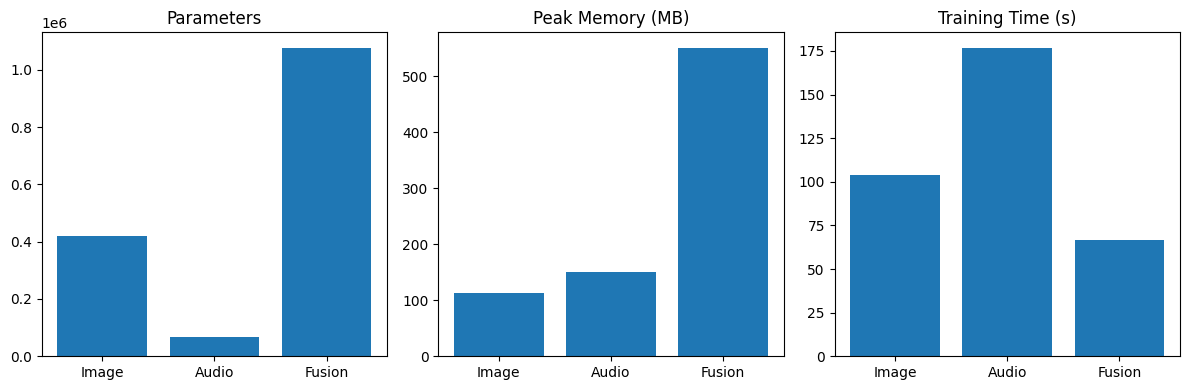

In [32]:
# Save results
param_dict = {
    "Image": image_params,
    "Audio": audio_params,
    "Fusion": fusion_params
}

time_dict = {
    "Image": image_time,
    "Audio": audio_time,
    "Fusion": fusion_time
}

memory_dict = {
    "Image": image_memory,
    "Audio": audio_memory,
    "Fusion": fusion_memory
}

# Plot
models = list(param_dict.keys())

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.bar(models, param_dict.values())
plt.title("Parameters")

plt.subplot(1,3,2)
plt.bar(models, memory_dict.values())
plt.title("Peak Memory (MB)")

plt.subplot(1,3,3)
plt.bar(models, time_dict.values())
plt.title("Training Time (s)")

plt.tight_layout()
plt.show()

Unimodal models trade expressive power for efficiency. With fewer parameters (audio << image), lower memory overhead, and simpler architectures, they are faster to train and deploy, but are fundamentally bounded by what a single modality can convey. By contrast, multimodal fusion capture ccross-modal interactions and exploit complementary signals, improving robustness and accuracy where modalities are informative together. This, however, comes at the cost of more parameters, higher memory, greater overfitting risk, and sensitivity to modality alignment.

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [33]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-v41j6oqm
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-v41j6oqm
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done


In [34]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO
from sklearn.decomposition import PCA

First, we create the model.

In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [36]:
from PIL import Image
!wget https://upload.wikimedia.org/wikipedia/commons/8/89/Portrait_Placeholder.png -O person.png

image_filename = "person.png"
image = Image.open(image_filename).convert("RGB")

--2026-02-27 06:41:48--  https://upload.wikimedia.org/wikipedia/commons/8/89/Portrait_Placeholder.png
Resolving upload.wikimedia.org (upload.wikimedia.org)... 198.35.26.112, 2620:0:863:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|198.35.26.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 216568 (211K) [image/png]
Saving to: ‘person.png’

person.png          100%[===================>] 211.49K  --.-KB/s    in 0.06s   

2026-02-27 06:41:48 (3.53 MB/s) - ‘person.png’ saved [216568/216568]



Now, we will prepare the prompt to use.

In [37]:
# Options to pick from
text_options = ["a photo of a sad person",
                "a photo of a happy person",
                "a photo of an angry person"]

image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [38]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalise features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
    a photo of an angry person: 50.83%
       a photo of a sad person: 42.16%
     a photo of a happy person: 6.99%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [51]:
# General model implementation for contrastive learning
class CLModel(nn.Module):
  def __init__(self, dim_x1, dim_x2, embedded_dim, temp):
    """
    General two-modality contrastive learning model.
    """
    super(CLModel, self).__init__()

    # Encoders (simple linear encoders; replace if needed)
    self.encoder1 = nn.Linear(dim_x1, embedded_dim)
    self.encoder2 = nn.Linear(dim_x2, embedded_dim)

    # Projectors to shared space
    self.projector1 = nn.Linear(embedded_dim, embedded_dim)
    self.projector2 = nn.Linear(embedded_dim, embedded_dim)

    # Learnable temp
    self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1/temp))

  def forward(self, x1, x2):
    # Extract raw features
    h1 = self.encoder1(x1)
    h2 = self.encoder2(x2)

    # Project to shared embedding space
    z1 = self.projector1(h1)
    z2 = self.projector2(h2)

    # Normalise embedding
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)

    return z1, z2

# Contrastive loss. This pulls positives together and pulls negatives apart
class ContrastiveLoss(nn.Module):
  """
  Symmetric contrastive loss for two modalities.
  """
  def __init__(self, model):
    super(ContrastiveLoss, self).__init__()

    self.model = model
    self.loss_fn = nn.CrossEntropyLoss()

  def forward(self, x1_emb, x2_emb):
    # Batch size
    batch_size = x1_emb.shape[0]

    # Similarity matrix (cosine sim since normalised), for which use einsum
    logits = torch.einsum('bd,cd->bc', x1_emb, x2_emb)

    # Apply temp scaling
    logits = logits * self.model.logit_scale.exp()

    # Labels
    labels = torch.arange(batch_size, device=logits.device)

    # Symmetric loss
    loss_i = self.loss_fn(logits, labels)
    loss_j = self.loss_fn(logits.T, labels)

    return (loss_i + loss_j) / 2

In [59]:
def train_model(model, contrastive_loss, dataloader,
                num_epochs=5, learning_rate=3e-4, device='cpu'):

    model = model.to(device)
    contrastive_loss = contrastive_loss.to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for data_a, data_b in dataloader:
            data_a = data_a.float().to(device)
            data_b = data_b.float().to(device)

            optimizer.zero_grad()

            emb_a, emb_b = model(data_a, data_b)

            loss = contrastive_loss(emb_a, emb_b)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

In [41]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device):
    model.eval()

    query_feat = model.encoder_a(query_input.unsqueeze(0).to(device))
    query_emb = F.normalize(model.projector_a(query_feat), dim=1)

    cand_feat = model.encoder_b(candidate_inputs.to(device))
    cand_emb = F.normalize(model.projector_b(cand_feat), dim=1)

    scores = torch.einsum('id, jd -> ij', query_emb, cand_emb)

    best_match_idx = scores.argmax().item()

    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item()}")

    return best_match_idx, scores

In [45]:
class RAVDESSContrastive(Dataset):
    def __init__(self, root_dir):
        # Now we search for WAV files (after conversion)
        self.files = glob.glob(f"{root_dir}/**/*.wav", recursive=True)

        if len(self.files) == 0:
            raise ValueError("No wav files found. Check your path.")

        self.mel_transform = T.MelSpectrogram(
            sample_rate=16000,
            n_mels=64
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        waveform, sr = torchaudio.load(self.files[idx])

        # Resample if needed
        if sr != 16000:
            waveform = torchaudio.functional.resample(waveform, sr, 16000)

        # Force fixed length (1 second = 16000 samples)
        waveform = waveform[:, :16000]

        if waveform.shape[1] < 16000:
            pad = 16000 - waveform.shape[1]
            waveform = F.pad(waveform, (0, pad))

        mel = self.mel_transform(waveform)

        return waveform.flatten(), mel.flatten()


In [48]:
# Create dataset and dataloader
dataset_root = "/content/ravdess"

dataset = RAVDESSContrastive(dataset_root)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Dataset size:", len(dataset))

Dataset size: 360


In [54]:
# Instantiate existing model
sample_a, sample_b = dataset[0]

model = CLModel(
    dim_x1=sample_a.numel(),
    dim_x2=sample_b.numel(),
    embedded_dim=256,
    temp=0.07
)

criterion = ContrastiveLoss(model)

In [60]:
# Train
train_model(model, criterion, dataloader, num_epochs=5, device='cuda')

Starting training for 5 epochs...
Epoch [1/5] | Loss: 3.3595
Epoch [2/5] | Loss: 3.4309
Epoch [3/5] | Loss: 3.2555
Epoch [4/5] | Loss: 3.1729
Epoch [5/5] | Loss: 3.1959


In [61]:
# Extract embeddings
model.eval()

all_wave = []
all_mel = []

with torch.no_grad():
    for data_a, data_b in dataloader:
        data_a = data_a.float().to('cuda')
        data_b = data_b.float().to('cuda')

        z1, z2 = model(data_a, data_b)

        all_wave.append(z1.cpu())
        all_mel.append(z2.cpu())

# Stack
wave_emb = torch.cat(all_wave, dim=0).numpy()
mel_emb = torch.cat(all_mel, dim=0).numpy()

print("Embeddings shape:", wave_emb.shape)

Embeddings shape: (360, 256)


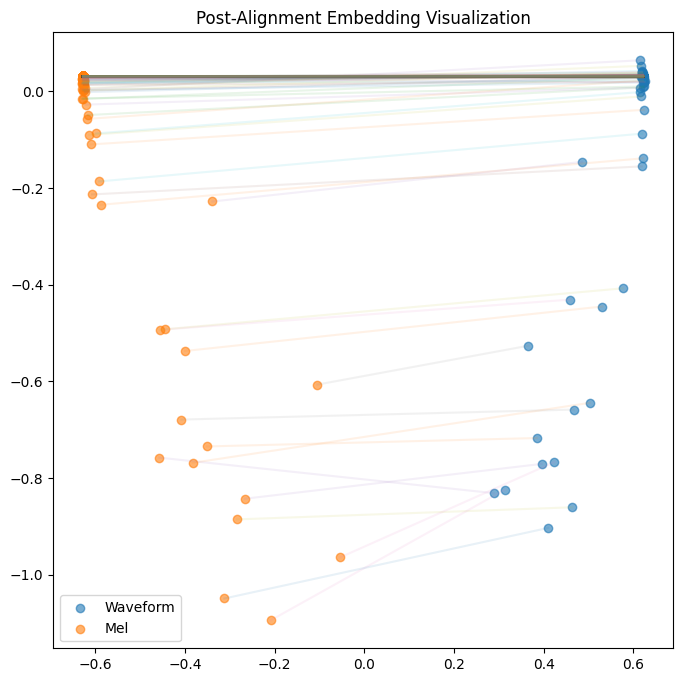

In [63]:
# Reduce to 2D (PCA)
combined = np.vstack([wave_emb, mel_emb])

pca = PCA(n_components=2)
reduced = pca.fit_transform(combined)

wave_2d = reduced[:len(wave_emb)]
mel_2d = reduced[len(wave_emb):]

# Visualise
plt.figure(figsize=(8,8))

# Plot waveform embeddings
plt.scatter(wave_2d[:,0], wave_2d[:,1], alpha=0.6, label="Waveform")

# Plot mel embeddings
plt.scatter(mel_2d[:,0], mel_2d[:,1], alpha=0.6, label="Mel")

# Draw lines between matching pairs
for i in range(len(wave_2d)):
    plt.plot(
        [wave_2d[i,0], mel_2d[i,0]],
        [wave_2d[i,1], mel_2d[i,1]],
        alpha=0.1
    )

plt.legend()
plt.title("Post-Alignment Embedding Visualization")
plt.show()

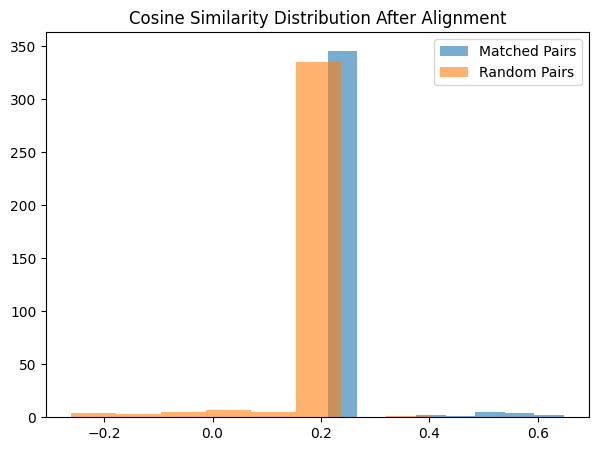

In [67]:
# We can also examine distance distribution
# Compute cosine similarity
wave_tensor = torch.tensor(wave_emb)
mel_tensor = torch.tensor(mel_emb)

# Positive similarities (matched pairs)
pos_sim = torch.sum(wave_tensor * mel_tensor, dim=1).numpy()

# Negative similarities (randomly shuffled)
perm = torch.randperm(len(mel_tensor))
neg_sim = torch.sum(wave_tensor * mel_tensor[perm], dim=1).numpy()

plt.figure(figsize=(7,5))
plt.hist(pos_sim, bins=8, alpha=0.6, label="Matched Pairs")
plt.hist(neg_sim, bins=8, alpha=0.6, label="Random Pairs")
plt.legend()
plt.title("Cosine Similarity Distribution After Alignment")
plt.show()

Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?
2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?
3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

1. The main surprising result is that the contrastive loss does not decrease steadily and remains relatively high (~3.1–3.4). Given that waveform and mel-spectrogram are two views of the same signal, I expected alignment to improve more consistently. Instead, training appears noisy and unstable. This likely reflects the small size of RAVDESS, the simplicity of the linear encoders, and the fact that both modalities are highly correlated (the mel-spectrogram is derived directly from the waveform). As a result, the model may not be learning rich cross-modal structure, but rather struggling to separate similar embeddings within small batches. This suggests that stronger encoders or larger batch sizes may be necessary for meaningful contrastive alignment in this setting.

2. Cross-entropy works because contrastive learning can be reframed as a classification problem. Given a batch of, say, $N$ audio-spectorgram pairs, the model computes similarity scores between every possible combination, producing an $N \times N$ matrix, wherein the diagonal entries are the correct matches, and every off-diagonal entry is a wrong one. Each row poses an $N$-way classification question: "given an audio clip, which spectrogram belongs to it?" Cross-entropy follows as the natural loss: it passes scores through softmax and penalises the omdel for assigning low probabiltiy to the correct match. Crucially, softmax is comparative: the correct pair is judged relative to every other score in the row, forcing the model to score the true match higher than all negatives. This is what drives the embedding space to organize correctly, wherein matched pairs pulled together, unmatched ones pushed apart.

3. I visualized post-alignment embeddings using PCA, plotting waveform and mel representations in 2D and connecting matched pairs. Alignment worked in some high-intensity emotion clips, where paired embeddings were close and connecting lines were short. These cases likely reflect strong acoustic cues (prosody + spectral energy) that are consistently captured by both views. However, many pairs remained far apart, especially for neutral or low-intensity emotions. This indicates failed alignment. The cosine similarity histogram confirms this: matched pairs show only a slight rightward shift relative to random pairs, with substantial overlap. Alignment exists but is weak.

The likely causes are: (1) small dataset size (RAVDESS is limited), (2) very simple encoders (single linear layers), and (3) the fact that mel-spectrograms are deterministically derived from waveforms, meaning the modalities are not independent views but highly correlated transformations. Stronger encoders or larger batch sizes would likely improve alignment quality.

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?
2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?

1. Contrastive learning for cross-modal alignment stood out the most. The core idea, that two completely different modalities can be projected into a shared embedding space without any label supervision, is elegant. Rather than predicting classes directly, the model learns by pulling matched pairs together and pushing unmatched ones apart, which reframes the whole problem geometrically. What makes it click is how simple inference becomes after training: a dot product is enough. That says a lot about how much work good representations can do on their own, including zero-shot generalization to unseen categories.

2. Contrastive alignment and multimodal fusion are both directly relevant to building systems that handle real, messy data. Shared embeddings mean the model can integrate signals from different sources and degrade more gracefully when one modality is noisy or missing, which matters in practice. Contrastive pretraining is also useful when labeled data is scarce, since it extracts structure before any supervised fine-tuning. Beyond performance, alignment-based methods produce similarity structures that are actually interpretable, which is useful when the goal isn't just accuracy but understanding why a model makes a decision.